In [ ]:
import geopandas as gpd
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds

from shapely.geometry import Polygon, LineString
from shapely.ops import unary_union
from shapely import wkt
from rtree import index
from shapely import MultiLineString
import matplotlib

"""
Code to perform the join operation over a patch GDF and a linestring GDF locally, and save that to a local asset. 
"""


LINESTRINGS_YEAR = "2024"
PATCHES_YEAR = "2024"

LINESTRINGS_PATH = f"../../gpkgs/haie_{LINESTRINGS_YEAR}.gpkg"#f"../../csvs/haie_{LINESTRINGS_YEAR}.csv"
PATCHES_PATH = f"../../gpkgs/france_patches_{PATCHES_YEAR}.gpkg"
OUTPUT_FILE_DESTINATION = f"../../gpkgs/haie_{LINESTRINGS_YEAR}_france_patches_{PATCHES_YEAR}_merged.gpkg"

ModuleNotFoundError: No module named 'geodatasets'

In [ ]:
#patches_gdf = gpd.GeoDataFrame.from_file(PATCHES_PATH, engine='pyogrio', driver="gkpg", use_arrow=True)
patches_gdf = gpd.read_file(PATCHES_PATH, engine='pyogrio', driver="gkpg", use_arrow=True)

patches_gdf.crs


/usr/lib/python3.10/contextlib.py:135: RuntimeWarning: driver GPKG does not support open option DRIVER
  return next(self.gen)


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
linestrings_gdf = gpd.GeoDataFrame.from_file(LINESTRINGS_PATH, engine='pyogrio', use_arrow=True)
if isinstance(linestrings_gdf["geometry"].iloc[0],str):
    linestrings_gdf["geometry"] = linestrings_gdf["geometry"].apply(wkt.loads)
linestrings_gdf = linestrings_gdf.to_crs("EPSG:4326")

patches_gdf = gpd.GeoDataFrame.from_file(PATCHES_PATH, engine='pyogrio', use_arrow=True)
if isinstance(patches_gdf["geometry"].iloc[0],str):
    patches_gdf["geometry"] = patches_gdf["geometry"].apply(wkt.loads)
patches_gdf = patches_gdf.to_crs("EPSG:4326")


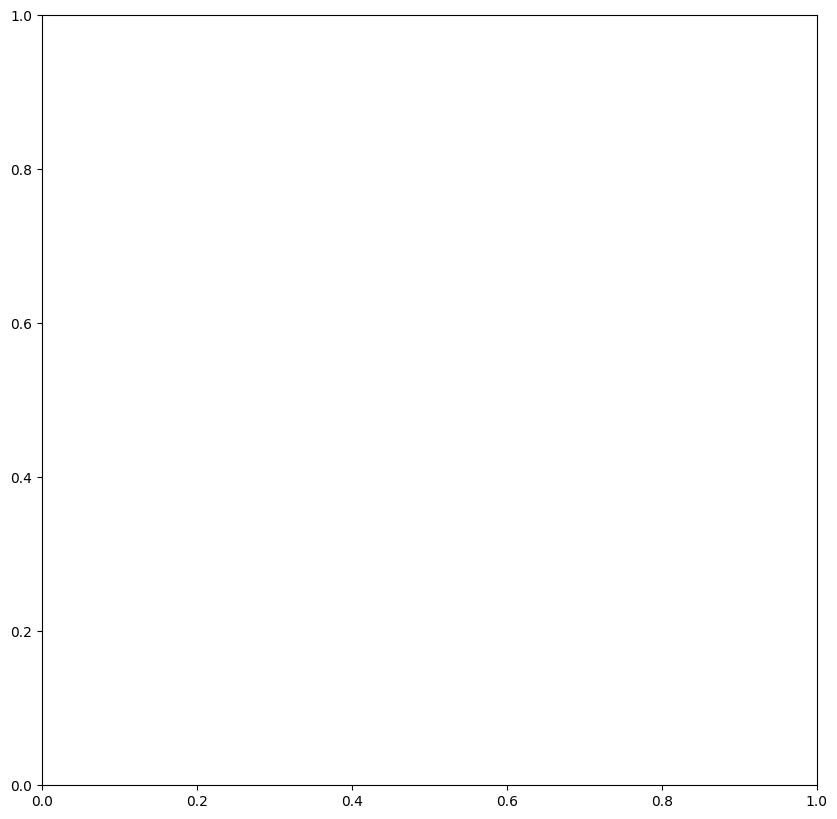

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# patches_gdf.plot(ax=ax,color="blue")
# linestrings_gdf.plot(ax=ax,color="red")
# plt.show()

In [ ]:
idx = index.Index()
for i, geom in enumerate(linestrings_gdf.geometry):
    idx.insert(i, geom.bounds)

owch


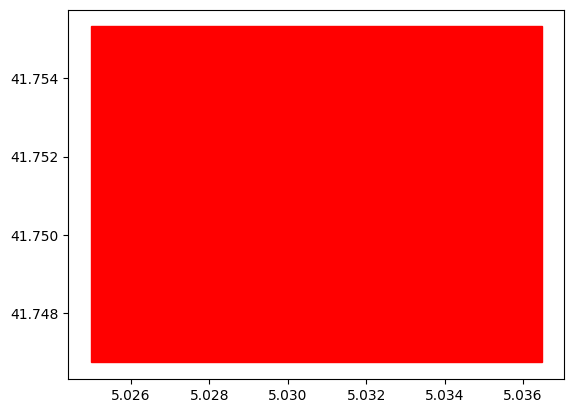

In [ ]:
import random 
def get_intersecting_lines(polygon):
    candidates = list(idx.intersection(polygon.bounds))
    
    intersecting_lines = []
    for i in candidates:
        line_geom = linestrings_gdf.iloc[i].geometry
        if polygon.intersects(line_geom):
            intersecting_lines.append(line_geom)
    
    return MultiLineString(intersecting_lines).intersection(polygon) if intersecting_lines else None

poly = patches_gdf.iloc[random.randint(0, len(patches_gdf))].geometry
lines = get_intersecting_lines(poly)
fig, ax = plt.subplots()

x,y = poly.exterior.xy
ax.fill(x,y,color="red")


try:
    for line in lines.geoms:
        x, y = line.xy
        ax.plot(x, y, color='blue', linewidth=2)
except:
   print("owch")
plt.show()

In [ ]:
len(patches_gdf)


1564325

In [ ]:
import time
start = time.time()

retval = patches_gdf[:10000].geometry.apply(get_intersecting_lines)
print((len(patches_gdf )/ 10000) * (time.time() - start))


10.66837825715542


In [ ]:
patches_gdf['hedgerows'] = patches_gdf.geometry.apply(get_intersecting_lines)


In [10]:
filtered_patches_gdf = patches_gdf.dropna(subset=["hedgerows"])

In [11]:
len(filtered_patches_gdf)

603564

In [12]:
filtered_patches_gdf.columns

Index(['geometry', 'hedgerows'], dtype='object')

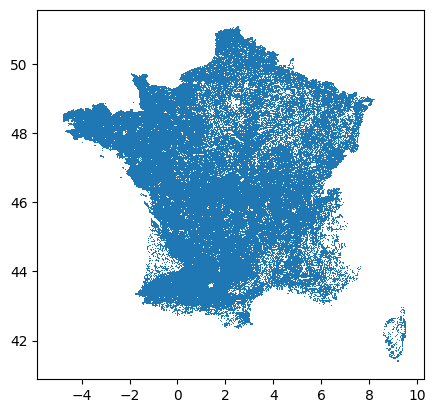

In [13]:
filtered_patches_gdf.plot()
plt.show()

In [14]:
filtered_patches_gdf["hedgerows"] = filtered_patches_gdf["hedgerows"].to_wkt()
filtered_patches_gdf.to_file(OUTPUT_FILE_DESTINATION, driver="GPKG")

/home/nathan/Desktop/BDA_integration/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
